# Task-based validation of RSI

This notebook tests whether individual differences in RSI are reflected by task-evoked activation and task performance.

In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from scipy.linalg import lstsq
from scipy.stats import mannwhitneyu, zscore
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.multitest import multipletests

# Find the project root from the current notebook working directory.
_here = Path.cwd().resolve()
project_root = next((p for p in [_here, *_here.parents] if (p / 'rise').is_dir() and (p / 'analysis').is_dir()), _here)
behavior_dir = project_root / 'analysis' / 'behavior'
info_dir = project_root / 'data' / 'HCP' / 'info'

# Precomputed task inputs live beside this notebook.
rsi_dir = project_root / 'results/rsi/HCP'
rsi_path = rsi_dir / 'test_rsi.csv'
activation_path = behavior_dir / 'test_indiv_mean_activation.csv'
md_mask_path = behavior_dir / 'MD_parcel_mask.npy'
task_ids_path = behavior_dir / 'tfMRI_exist_ids.pkl'

task_contrasts = ['MATH-STORY', 'REL-MATCH', '2BK-0BK']
task_behavior = ['Language_Task_Acc', 'Relational_Task_Acc', 'WM_Task_Acc']


## Load subjects, RSI, and covariates

The task-availability list is used to preserve the same subject ordering as the precomputed activation table.


In [2]:
def regress_covariates(data, covariates):
    """Match the historical residualization used in the behavior analyses."""
    values = np.asarray(data, dtype=float)
    if values.ndim == 1:
        values = values[:, None]
    covariate_values = np.asarray(covariates, dtype=float)
    if covariate_values.ndim == 1:
        covariate_values = covariate_values[:, None]

    design = np.column_stack([covariate_values, np.ones(len(covariate_values))])
    residuals = np.empty_like(values)
    for column in range(values.shape[1]):
        coefficients = lstsq(design, values[:, column])[0]
        residuals[:, column] = values[:, column] - covariate_values @ coefficients[:-1]

    # Keep the original feature range, as in the original notebook.
    result = np.empty_like(residuals)
    for column in range(values.shape[1]):
        low, high = np.nanmin(values[:, column]), np.nanmax(values[:, column])
        if low == high:
            result[:, column] = values[:, column]
        else:
            result[:, column] = MinMaxScaler(feature_range=(low, high)).fit_transform(
                residuals[:, column, None]
            ).ravel()
    return result


def clean_and_fill(data, max_missing_fraction=0.1):
    data = data.copy()
    too_many_missing = data.isna().mean() > max_missing_fraction
    if too_many_missing.any():
        print('Dropping columns with too many missing values:', list(data.columns[too_many_missing]))
        data = data.loc[:, ~too_many_missing]
    return data.fillna(data.mean(numeric_only=True))


def load_hcp_covariates(subject_ids):
    info = pd.read_csv(info_dir / 'hcp_998.csv')
    info['age'] = info['Age_in_Yrs']
    info['sex'] = np.where(info['Gender'].eq('M'), 1, -1)
    info = info.set_index('Subject')
    return info.loc[list(subject_ids), ['age', 'sex']]

train_ids = pd.read_csv(info_dir / 'train.txt', header=None)[0].astype(int).tolist()
test_ids = pd.read_csv(info_dir / 'test.txt', header=None)[0].astype(int).tolist()
test_rsi = pd.read_csv(rsi_path, index_col=0)
test_rsi.index = test_rsi.index.astype(int)

with open(task_ids_path, 'rb') as handle:
    task_subject_ids = [int(subject_id) for subject_id in pickle.load(handle)]

test_index = {subject_id: index for index, subject_id in enumerate(test_ids)}
test_task_ids = [subject_id for subject_id in task_subject_ids if subject_id in test_index]
test_rsi = test_rsi.iloc[[test_index[sid] for sid in test_task_ids]].copy()

covariates = load_hcp_covariates(test_task_ids)
test_rsi_reg = pd.DataFrame(
    regress_covariates(test_rsi.values, covariates.values),
    index=test_rsi.index,
    columns=test_rsi.columns,
)

print(f'Task subjects in the RSI test set: {len(test_task_ids)}')


Task subjects in the RSI test set: 684


## Summarize RSI in the MD system mask

The MD mask identifies the prior parcels used for the task validation. The subject-level score is the mean RSI over those parcels.


In [3]:
md_mask = np.asarray(np.load(md_mask_path)).astype(bool).ravel()
if len(md_mask) != test_rsi_reg.shape[1]:
    raise ValueError(f'MD mask has {len(md_mask)} parcels, but RSI has {test_rsi_reg.shape[1]} columns.')

md_rsi = pd.DataFrame(
    test_rsi_reg.loc[:, md_mask].mean(axis=1),
    index=test_rsi_reg.index,
    columns=['MD_mean'],
)


## Compare task-evoked activation


In [4]:
activation = pd.read_csv(activation_path)
if len(activation) != len(test_task_ids):
    raise ValueError(
        f'Activation rows ({len(activation)}) do not match task subjects ({len(test_task_ids)}). '
        'Keep the precomputed activation table aligned with tfMRI_exist_ids.pkl.'
    )
activation.index = test_task_ids
activation = activation.loc[:, task_contrasts].replace([np.inf, -np.inf], np.nan).fillna(0)
activation_reg = pd.DataFrame(
    zscore(regress_covariates(activation.values, covariates.values), axis=0),
    index=activation.index,
    columns=activation.columns,
)

ranked_subjects = md_rsi['MD_mean'].dropna().sort_values()
n_group = max(1, int(len(ranked_subjects) * 0.2))
low_ids = ranked_subjects.index[:n_group]
high_ids = ranked_subjects.index[-n_group:]
print(f'Low/high RSI groups: {n_group} subjects each')

def compare_groups(values, feature_names):
    rows, high_values, low_values = [], {}, {}
    for feature in feature_names:
        high = values.loc[high_ids, feature].dropna().to_numpy()
        low = values.loc[low_ids, feature].dropna().to_numpy()
        statistic, p_value = mannwhitneyu(high, low, alternative='greater')
        high_values[feature], low_values[feature] = high, low
        rows.append({
            'feature': feature,
            'high_mean': high.mean(),
            'low_mean': low.mean(),
            'mean_difference': high.mean() - low.mean(),
            'effect_size': 1 - 2 * statistic / (len(high) * len(low)),
            'p_value': p_value,
        })
    result = pd.DataFrame(rows).set_index('feature')
    result['p_fdr'] = multipletests(result['p_value'], method='fdr_bh')[1]
    result['significant'] = result['p_fdr'] < 0.05
    return result, high_values, low_values

activation_results, activation_high, activation_low = compare_groups(activation_reg, task_contrasts)


Low/high RSI groups: 136 subjects each


## Compare task performance

The same high/low RSI split is applied to the three HCP task accuracy measures.


In [5]:
behavior = pd.read_csv(info_dir / 'hcp_998.csv').set_index('Subject')
behavior = clean_and_fill(behavior.loc[test_task_ids, task_behavior])
behavior_reg = pd.DataFrame(
    zscore(regress_covariates(behavior.values, covariates.values), axis=0),
    index=behavior.index,
    columns=behavior.columns,
)
behavior_results, behavior_high, behavior_low = compare_groups(behavior_reg, task_behavior)

## Display group comparisons


In [6]:
import colorsys


def _adjust_saturation(color, factor=1.0):
    rgb = mcolors.to_rgb(color)
    h, s, v = colorsys.rgb_to_hsv(*rgb)
    return colorsys.hsv_to_rgb(h, np.clip(s * factor, 0, 1), v)


def _adjust_value(color, factor=1.0):
    rgb = mcolors.to_rgb(color)
    h, s, v = colorsys.rgb_to_hsv(*rgb)
    return colorsys.hsv_to_rgb(h, s, np.clip(v * factor, 0, 1))


def _format_p(p_value):
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'


def plot_group_comparison(
    result,
    high_values,
    low_values,
    title,
    y_label,
    figsize=(5.6, 3.15),
    box_width=0.10,
    within_gap=0.25,
    group_gap=0.75,
    point_size=3,
    jitter_width=0.15,
    point_alpha=0.20,
):
    """Draw the original paired low/high RSI boxplot layout."""
    top_rgb = _adjust_saturation('#E87A5D', 0.6)
    low_rgb = _adjust_saturation('#3A90C4', 0.6)
    top_edge = _adjust_value(top_rgb, 0.95)
    low_edge = _adjust_value(low_rgb, 0.95)
    top_fill = (*top_rgb, 0.55)
    low_fill = (*low_rgb, 0.55)

    features = list(result.index)
    centers = np.arange(len(features)) * group_gap
    low_positions = centers - within_gap / 2
    high_positions = centers + within_gap / 2
    rng = np.random.default_rng(42)
    all_values = []
    bracket_positions = []
    fig, ax = plt.subplots(figsize=figsize)

    for index, feature in enumerate(features):
        low = np.asarray(low_values[feature], dtype=float)
        high = np.asarray(high_values[feature], dtype=float)
        low = low[np.isfinite(low)]
        high = high[np.isfinite(high)]
        combined = np.concatenate([low, high])
        all_values.append(combined)

        low_box = ax.boxplot(
            [low], positions=[low_positions[index]], widths=box_width,
            patch_artist=True, showfliers=False, zorder=3,
            medianprops={'color': low_edge, 'linewidth': 1.5},
            whiskerprops={'color': low_edge, 'linewidth': 1.0},
            capprops={'color': low_edge, 'linewidth': 1.0},
        )
        for patch in low_box['boxes']:
            patch.set_facecolor(low_fill)
            patch.set_edgecolor(low_edge)
            patch.set_linewidth(1.0)

        high_box = ax.boxplot(
            [high], positions=[high_positions[index]], widths=box_width,
            patch_artist=True, showfliers=False, zorder=3,
            medianprops={'color': top_edge, 'linewidth': 1.5},
            whiskerprops={'color': top_edge, 'linewidth': 1.0},
            capprops={'color': top_edge, 'linewidth': 1.0},
        )
        for patch in high_box['boxes']:
            patch.set_facecolor(top_fill)
            patch.set_edgecolor(top_edge)
            patch.set_linewidth(1.0)

        low_x = low_positions[index] + rng.normal(0, box_width * jitter_width, len(low))
        high_x = high_positions[index] + rng.normal(0, box_width * jitter_width, len(high))
        ax.scatter(low_x, low, s=point_size, color=low_edge, alpha=point_alpha, linewidths=0, zorder=4)
        ax.scatter(high_x, high, s=point_size, color=top_edge, alpha=point_alpha, linewidths=0, zorder=4)

        local_range = np.ptp(combined) or 1.0
        bracket_y = np.max(combined) + local_range * 0.12
        bracket_height = local_range * 0.04
        ax.plot(
            [low_positions[index], low_positions[index], high_positions[index], high_positions[index]],
            [bracket_y - bracket_height, bracket_y, bracket_y, bracket_y - bracket_height],
            color='#333333', linewidth=0.8, zorder=5,
        )
        ax.text(
            centers[index], bracket_y + local_range * 0.02,
            _format_p(result.loc[feature, 'p_fdr']), ha='center', va='bottom',
            fontsize=10, color='#333333',
        )
        bracket_positions.append(bracket_y)

    all_values = np.concatenate(all_values)
    y_min, y_max = np.min(all_values), max(np.max(all_values), max(bracket_positions))
    y_range = y_max - y_min or 1.0
    ax.set_ylim(y_min - y_range * 0.25, y_max + y_range * 0.20)
    ax.set_xlim(centers[0] - 0.45, centers[-1] + 0.45)
    ax.set_xticks(centers)
    ax.set_xticklabels(features, fontsize=10)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_ylabel(y_label, fontsize=12, labelpad=3)
    ax.set_title(title, fontsize=16, pad=25, color='#333333')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('gray')
    ax.spines['bottom'].set_color('gray')
    ax.tick_params(direction='out', length=4, width=0.8, color='gray')
    ax.legend(
        handles=[
            Patch(facecolor=low_fill, edgecolor=low_edge, linewidth=1.0, label='Low RSI'),
            Patch(facecolor=top_fill, edgecolor=top_edge, linewidth=1.0, label='High RSI'),
        ], frameon=False, loc='lower right', fontsize=9, handlelength=1,
    )
    plt.tight_layout()
    plt.show()


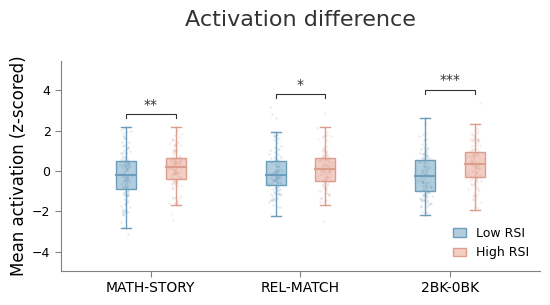

In [7]:
plot_group_comparison(
    activation_results, activation_high, activation_low,
    title='Activation difference', y_label='Mean activation (z-scored)',
)


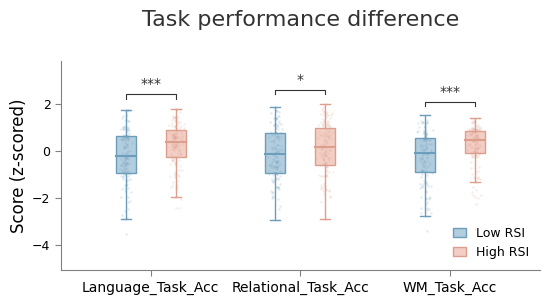

In [8]:
plot_group_comparison(
    behavior_results, behavior_high, behavior_low,
    title='Task performance difference', y_label='Score (z-scored)',
)
